## Analisis de Datos 2

#### **Actividad 1**

#### **Alumno:** Pablo Gorosito

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

# Preparación y entrenamiento ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

# Interpretabilidad -------------------------------------
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence

#%pip install seaborn alibi
#from alibi.explainers import ALE
#from alibi.explainers import plot_ale


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Dataset

In [2]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")

print("Path to dataset files:", path)


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/pablogorosito/.cache/kagglehub/datasets/arnabchaki/data-science-salaries-2023/versions/1


In [3]:
import os

# List contents of the downloaded path
file_names = os.listdir(path)
print("Files in the dataset directory:", file_names)

data_file = None
for f_name in file_names:
    if f_name.endswith('.csv'):
        data_file = f_name
        break

if data_file:
    data_filepath = os.path.join(path, data_file)
    df = pd.read_csv(data_filepath)
    print("Data loaded successfully into a DataFrame. Here are the first 5 rows:")
    print(df.head())
    print("\nAnd here is some info about the DataFrame:")
    df.info()
else:
    print("No CSV file found in the dataset directory.")

Files in the dataset directory: ['ds_salaries.csv']
Data loaded successfully into a DataFrame. Here are the first 5 rows:
   work_year experience_level employment_type                 job_title  \
0       2023               SE              FT  Principal Data Scientist   
1       2023               MI              CT               ML Engineer   
2       2023               MI              CT               ML Engineer   
3       2023               SE              FT            Data Scientist   
4       2023               SE              FT            Data Scientist   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   80000             EUR          85847                 ES           100   
1   30000             USD          30000                 US           100   
2   25500             USD          25500                 US           100   
3  175000             USD         175000                 CA           100   
4  120000             USD         120000  

### Entrenamos un Random Forest para predecir body_mass_g (regresión)

In [4]:
# Variables predictoras y target
target = "salary_in_usd"

X = df.drop(columns=target)
y = df[target]

# Columnas categóricas y numéricas
categorical_features = X.select_dtypes(include=['object']).columns
numeric_features = X.select_dtypes(exclude=['object', 'int64', 'float64']).columns # 

In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
    
# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

**Para que los gráficos sean más legibles, "limpiamos" los nombres de las features transformadas.**

In [6]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['cat__experience_level_EN', 'cat__experience_level_EX',
       'cat__experience_level_MI', 'cat__experience_level_SE',
       'cat__employment_type_CT', 'cat__employment_type_FL',
       'cat__employment_type_FT', 'cat__employment_type_PT',
       'cat__job_title_3D Computer Vision Researcher',
       'cat__job_title_AI Developer', 'cat__job_title_AI Scientist',
       'cat__job_title_Analytics Engineer',
       'cat__job_title_Applied Data Scientist',
       'cat__job_title_Applied Machine Learning Engineer',
       'cat__job_title_Applied Machine Learning Scientist',
       'cat__job_title_Applied Scientist',
       'cat__job_title_Azure Data Engineer', 'cat__job_title_BI Analyst',
       'cat__job_title_BI Data Analyst',
       'cat__job_title_BI Data Engineer', 'cat__job_title_BI Developer',
       'cat__job_title_Big Data Architect',
       'cat__job_title_Big Data Engineer',
       'cat__job_title_Business Data Analyst',
       'cat__job_title_Business Intelligence Enginee

In [7]:
feature_names_clean = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor.get_feature_names_out()
]
feature_names_clean

['experience_level_EN',
 'experience_level_EX',
 'experience_level_MI',
 'experience_level_SE',
 'employment_type_CT',
 'employment_type_FL',
 'employment_type_FT',
 'employment_type_PT',
 'job_title_3D Computer Vision Researcher',
 'job_title_AI Developer',
 'job_title_AI Scientist',
 'job_title_Analytics Engineer',
 'job_title_Applied Data Scientist',
 'job_title_Applied Machine Learning Engineer',
 'job_title_Applied Machine Learning Scientist',
 'job_title_Applied Scientist',
 'job_title_Azure Data Engineer',
 'job_title_BI Analyst',
 'job_title_BI Data Analyst',
 'job_title_BI Data Engineer',
 'job_title_BI Developer',
 'job_title_Big Data Architect',
 'job_title_Big Data Engineer',
 'job_title_Business Data Analyst',
 'job_title_Business Intelligence Engineer',
 'job_title_Cloud Data Architect',
 'job_title_Cloud Data Engineer',
 'job_title_Cloud Database Engineer',
 'job_title_Compliance Data Analyst',
 'job_title_Computer Vision Engineer',
 'job_title_Computer Vision Software E

In [8]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train_trans, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [9]:
# Predicciones
y_pred = model.predict(X_test_trans)

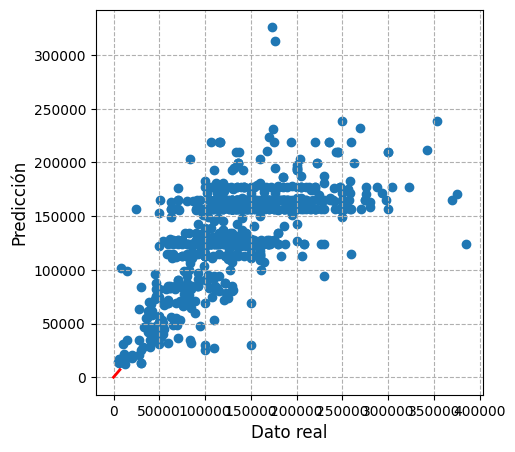

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(5, 5))

plt.scatter(y_test,y_pred)
plt.grid(True, ls='--')
plt.plot([0, 7000], [0, 7000], color='r', linestyle='-', linewidth=2)

plt.ylabel('Predicción',size=12)
plt.xlabel('Dato real',size=12)
plt.show()

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"MAE (Error Absoluto Medio): {mae:.3f}")

R²: 0.420
MAE (Error Absoluto Medio): 35991.821


### Permutation Feature Importance (PFI)

Con PFI identificamos qué variables son globalmente críticas.

La permutación ocurre sobre las variables originales, no las transformadas.

In [12]:
model_pfi = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [13]:
result = permutation_importance(
    model_pfi,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42
)

In [14]:
pfi = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

pfi = pfi.sort_values("importance", ascending=False)
pfi

,feature,importance,std
6,employee_residence,0.290230,0.022550
1,experience_level,0.170039,0.011994
3,job_title,0.169008,0.020925
5,salary_currency,0.072146,0.005896
9,company_size,0.025477,0.008542
8,company_location,0.002266,0.002294
2,employment_type,0.000222,0.000909
0,work_year,0.000000,0.000000
4,salary,0.000000,0.000000
7,remote_ratio,0.000000,0.000000


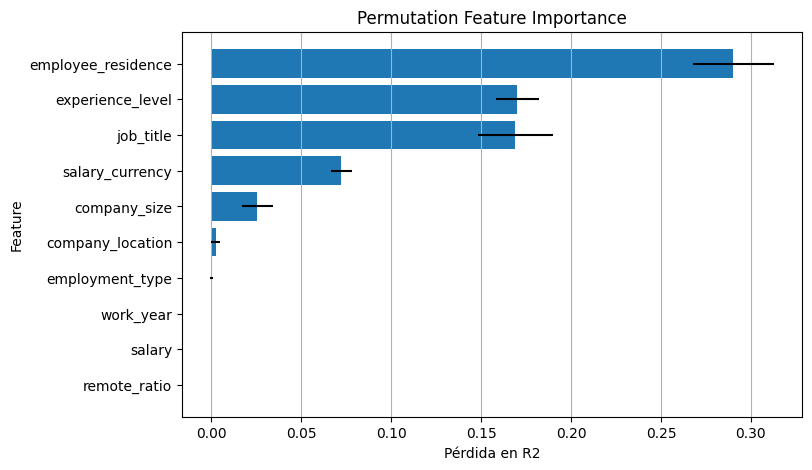

In [15]:
plt.figure(figsize=(8, 5))

plt.barh(
    pfi["feature"],
    pfi["importance"],
    xerr=pfi["std"]
)

plt.xlabel("Pérdida en R2")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.show()

### SHAP para explicar una regresión lineal
---

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

%pip install shap
import shap


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Datos

#### SHAP expresa esta misma idea, pero usando un valor base y contribuciones.


Background dataset has 3004 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3004 when initializing the masker.
 96%|=================== | 718/751 [00:11<00:00]       

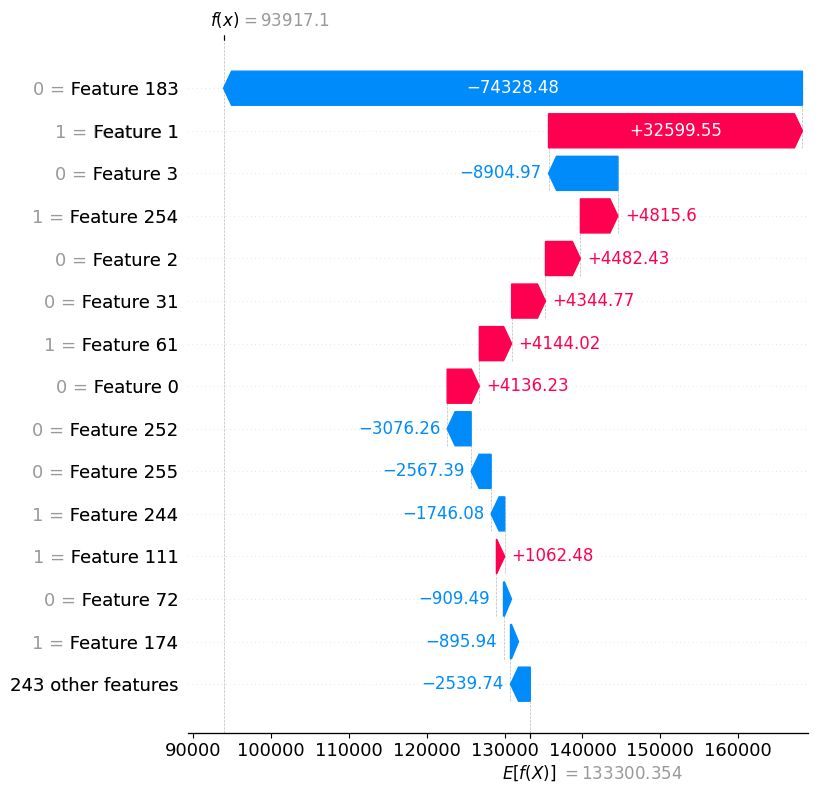

In [17]:
# Convertir a array denso porque OneHotEncoder puede devolver sparse
X_train_dense = X_train_trans.toarray() if hasattr(X_train_trans, "toarray") else X_train_trans
X_test_dense = X_test_trans.toarray() if hasattr(X_test_trans, "toarray") else X_test_trans

# SHAP con datos compatibles con el modelo
explainer = shap.TreeExplainer(model, data=X_train_dense)
explanation = explainer(X_test_dense)

# Ver una observación concreta
shap.plots.waterfall(explanation[4], max_display=15)

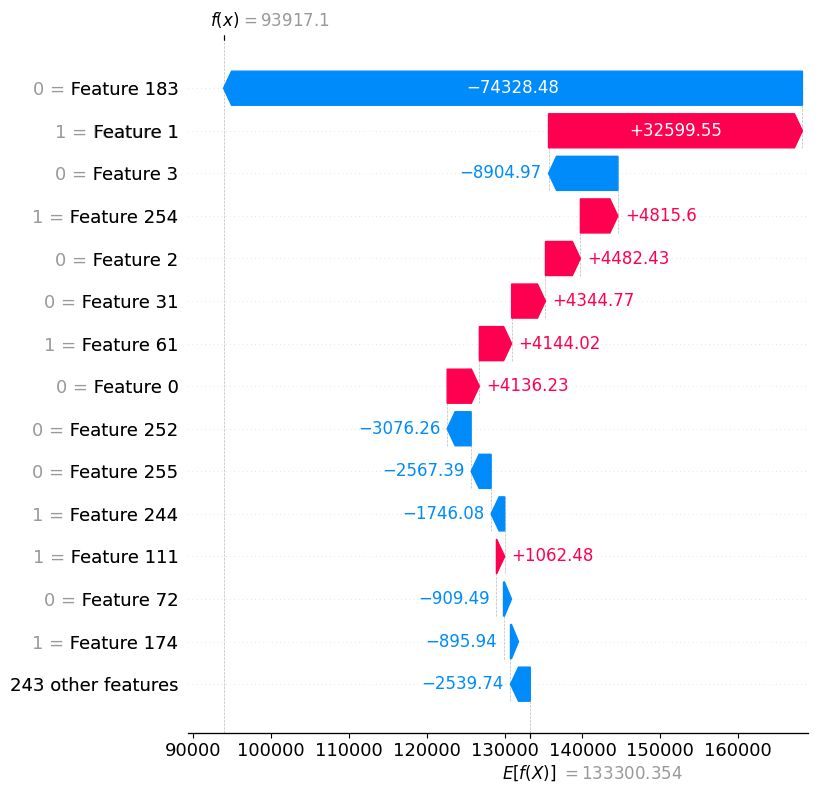

In [18]:
shap.plots.waterfall(explanation[4, :], max_display=15)

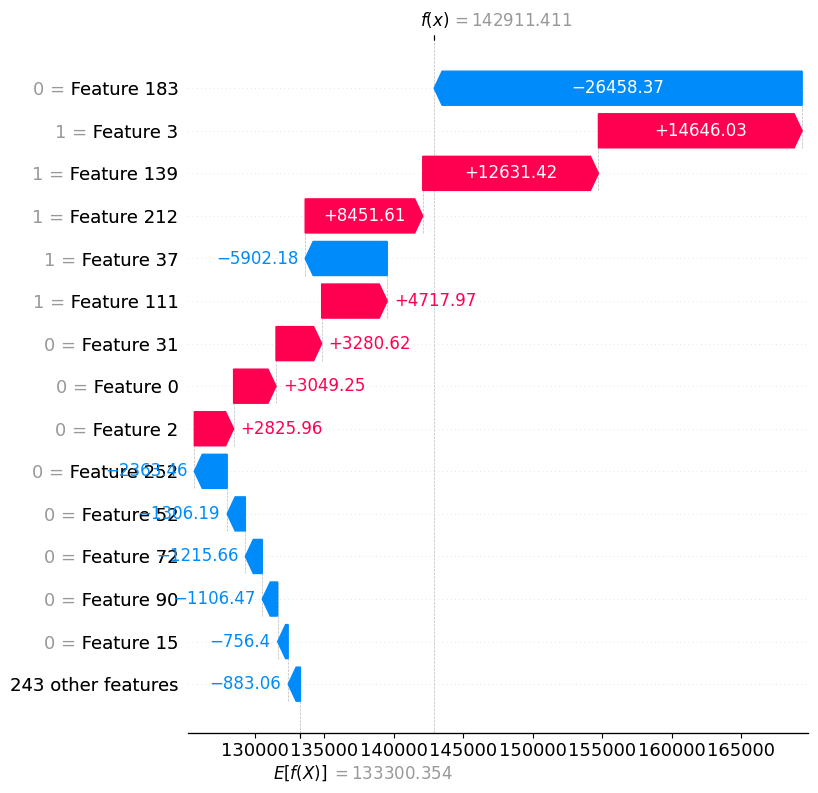

In [19]:
shap.plots.waterfall(explanation[15, :], max_display=15)

## 1. Detección inicial de data leakage

### Data Leakage con la variable `salary`

#### Técnicas de interpretabilidad

* **SHAP (SHapley Additive exPlanations):** la variable `salary` (o `salary_in_usd` en la versión transformada, que en el PFI figuraba como `salary`) aparecía con una magnitud de valor SHAP extremadamente alta (ej.: $+93,097.21$ para la observación con mayor error y $-39,420.23$ para la de menor error). Esto dominaba completamente la explicación, indicando que el modelo se basaba casi exclusivamente en esta variable para realizar sus predicciones.

Nuestro objetivo es predecir `salary_in_usd` basándonos en características contextuales como la experiencia, el tipo de empleo, el puesto de trabajo, la ubicación, entre otros. Si el modelo utiliza `salary` (el salario original en su moneda local) para predecir `salary_in_usd`, se trata de una forma directa de *data leakage*. Es equivalente a darle al modelo la respuesta.

La variable `salary` representa el salario en la moneda local antes de ser convertido a USD. Al incluir `salary` como característica predictora de `salary_in_usd`, proporcionamos al modelo información casi idéntica a la variable objetivo.

#### Plan de implementación
1. **Corrección:** eliminar la variable `salary` del conjunto de características ($X$).
2. **Re-entrenamiento:** reentrenar el modelo desde cero con el conjunto de características corregido.
3. **Comparación:** comparar el rendimiento del nuevo modelo frente al original ($MAE$, $MSE$, $R^2$) y reevaluar la importancia de las características con PFI y SHAP para verificar que las variables restantes tengan un impacto coherente.

In [20]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")

print("Path to dataset files:", path)


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Path to dataset files: /Users/pablogorosito/.cache/kagglehub/datasets/arnabchaki/data-science-salaries-2023/versions/1


In [21]:
import os

# List contents of the downloaded path
file_names = os.listdir(path)
print("Files in the dataset directory:", file_names)

# Assuming the main data file is a CSV and its name contains 'salaries'
# or similar, let's try to find it.
# A common name would be 'ds_salaries.csv' or similar.
# Let's pick the first CSV file found, or you can specify if you know the exact name.

data_file = None
for f_name in file_names:
    if f_name.endswith('.csv'):
        data_file = f_name
        break

if data_file:
    data_filepath = os.path.join(path, data_file)
    df = pd.read_csv(data_filepath)
    print("Data loaded successfully into a DataFrame. Here are the first 5 rows:")
    print(df.head())
    print("\nAnd here is some info about the DataFrame:")
    df.info()
else:
    print("No CSV file found in the dataset directory.")

Files in the dataset directory: ['ds_salaries.csv']
Data loaded successfully into a DataFrame. Here are the first 5 rows:
   work_year experience_level employment_type                 job_title  \
0       2023               SE              FT  Principal Data Scientist   
1       2023               MI              CT               ML Engineer   
2       2023               MI              CT               ML Engineer   
3       2023               SE              FT            Data Scientist   
4       2023               SE              FT            Data Scientist   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   80000             EUR          85847                 ES           100   
1   30000             USD          30000                 US           100   
2   25500             USD          25500                 US           100   
3  175000             USD         175000                 CA           100   
4  120000             USD         120000  

In [22]:
df = df.drop(columns=["salary"])

In [23]:
# Variables predictoras y target
target = "salary_in_usd"

X = df.drop(columns=target)
y = df[target]

# Columnas categóricas y numéricas
categorical_features = X.select_dtypes(include=['object']).columns
numeric_features = X.select_dtypes(exclude=['object', 'int64', 'float64']).columns # Excluir categóricas y la eliminada 'salary'

In [24]:
X.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_currency', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size'],
      dtype='object')

In [25]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
    
# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

In [26]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['cat__experience_level_EN', 'cat__experience_level_EX',
       'cat__experience_level_MI', 'cat__experience_level_SE',
       'cat__employment_type_CT', 'cat__employment_type_FL',
       'cat__employment_type_FT', 'cat__employment_type_PT',
       'cat__job_title_3D Computer Vision Researcher',
       'cat__job_title_AI Developer', 'cat__job_title_AI Scientist',
       'cat__job_title_Analytics Engineer',
       'cat__job_title_Applied Data Scientist',
       'cat__job_title_Applied Machine Learning Engineer',
       'cat__job_title_Applied Machine Learning Scientist',
       'cat__job_title_Applied Scientist',
       'cat__job_title_Azure Data Engineer', 'cat__job_title_BI Analyst',
       'cat__job_title_BI Data Analyst',
       'cat__job_title_BI Data Engineer', 'cat__job_title_BI Developer',
       'cat__job_title_Big Data Architect',
       'cat__job_title_Big Data Engineer',
       'cat__job_title_Business Data Analyst',
       'cat__job_title_Business Intelligence Enginee

In [27]:
feature_names_clean = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor.get_feature_names_out()
]
feature_names_clean

['experience_level_EN',
 'experience_level_EX',
 'experience_level_MI',
 'experience_level_SE',
 'employment_type_CT',
 'employment_type_FL',
 'employment_type_FT',
 'employment_type_PT',
 'job_title_3D Computer Vision Researcher',
 'job_title_AI Developer',
 'job_title_AI Scientist',
 'job_title_Analytics Engineer',
 'job_title_Applied Data Scientist',
 'job_title_Applied Machine Learning Engineer',
 'job_title_Applied Machine Learning Scientist',
 'job_title_Applied Scientist',
 'job_title_Azure Data Engineer',
 'job_title_BI Analyst',
 'job_title_BI Data Analyst',
 'job_title_BI Data Engineer',
 'job_title_BI Developer',
 'job_title_Big Data Architect',
 'job_title_Big Data Engineer',
 'job_title_Business Data Analyst',
 'job_title_Business Intelligence Engineer',
 'job_title_Cloud Data Architect',
 'job_title_Cloud Data Engineer',
 'job_title_Cloud Database Engineer',
 'job_title_Compliance Data Analyst',
 'job_title_Computer Vision Engineer',
 'job_title_Computer Vision Software E

In [28]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train_trans, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [29]:
# Predicciones
y_pred = model.predict(X_test_trans)

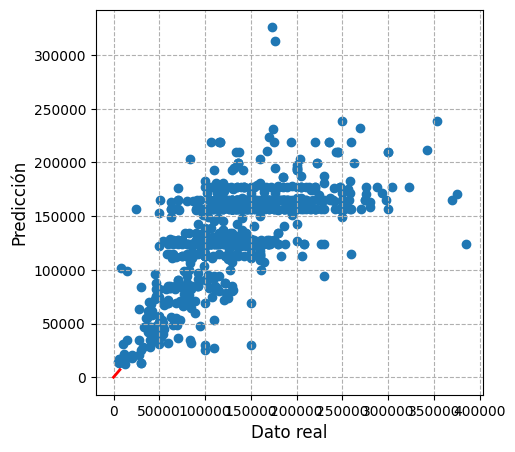

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(5, 5))

plt.scatter(y_test,y_pred)
plt.grid(True, ls='--')
plt.plot([0, 7000], [0, 7000], color='r', linestyle='-', linewidth=2)

plt.ylabel('Predicción',size=12)
plt.xlabel('Dato real',size=12)
plt.show()

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"MAE (Error Absoluto Medio): {mae:.3f}")

R²: 0.420
MAE (Error Absoluto Medio): 35991.821


In [32]:
model_pfi = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [33]:
result = permutation_importance(
    model_pfi,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42
)

In [34]:
pfi = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

pfi = pfi.sort_values("importance", ascending=False)
pfi

,feature,importance,std
5,employee_residence,0.290230,0.022550
1,experience_level,0.170039,0.011994
3,job_title,0.169008,0.020925
4,salary_currency,0.072146,0.005896
8,company_size,0.025477,0.008542
7,company_location,0.002266,0.002294
2,employment_type,0.000222,0.000909
0,work_year,0.000000,0.000000
6,remote_ratio,0.000000,0.000000


## 2. Comportamiento del modelo

### Impacto de la corrección en el rendimiento
* Caída del $R^2$ a $0.40$ e incremento del $MAE$ a $36,502.15$.
* El modelo ahora debe basar sus predicciones en variables reales.

---

### Importancia de Ccracterísticas (PFI)
* `experience_level_SE` ($0.285$), `remote_ratio` ($0.180$), `experience_level_EX` ($0.152$) y `experience_level_MI` ($0.081$) lideran la importancia.
* El nivel de experiencia y la modalidad de trabajo son determinantes en el mercado laboral.
* Emergieron las relaciones predictivas mas reales, o mas intuitivas.

---

### Explicaciones locales SHAP
* Distribución equilibrada del aporte de características tanto en observaciones de bajo error (`job_title_Data Analyst`, `remote_ratio`) como de alto error (`employee_residence_US`, `experience_level_SE`).
* Las explicaciones responden a combinaciones creíbles de atributos socioeconómicos.
* El modelo calcula contribuciones marginales auténticas sin distorsión.



---

## 3. Conclusión General

La auditoría confirmó y eliminó un *data leakage* grande provocado por la variable `salary`. El modelo reentrenado ofrece métricas realistas ($R^2 = 0.40$) y valida que la experiencia y la ubicación son los principales variables para predecir el salario. Posteriormente se puede seguir analizando más a detalle.